# 02 - Daten visualisieren

Dieses Notebook betrachtet ausschließlich Rohdaten und Targets. Oben wird
ein Zielgas gewählt; alle folgenden Abbildungen aktualisieren sich nach
erneutem Ausführen der Zellen. Es werden keine abgeleiteten Merkmale
erzeugt. Für vergleichbare R²-/Fehlerwerte wird am Ende lediglich eine
ausdrücklich gekennzeichnete lineare Einpunkt-Baseline angepasst.

## Software, Bedienung und Plotparameter

Oben werden nur GAS und TRANSFORM verändert. Danach sollte **Run All** verwendet
werden, damit jede Grafik dieselbe Auswahl zeigt.

**Eingabeparameter**

- GAS akzeptiert einen Namen aus GAS_TARGETS, beispielsweise "acetone",
  "hydrogen" oder "ethyl_acetate".
- TRANSFORM ist "stored" oder "log1p". Die zweite Variante ist eine zusätzliche
  Transformation und nicht der ursprüngliche Widerstand.

**Verwendete Software**

- NumPy lädt NPZ-Dateien, berechnet Quantile, Korrelationen und die lineare
  Kleinste-Quadrate-Lösung.
- Matplotlib erzeugt Histogramme, ECDF, Scatterplots, Signalbänder und
  Temperaturprofile. figsize ändert die Größe, alpha die Transparenz, s die
  Punktgröße und bins die Anzahl der Histogrammklassen.
- dataset_pipeline liefert die unveränderten UGM-Splits, Zielnamen,
  Temperaturgrenzen und Exporte.

Die lineare Einpunkt-Baseline löst Ziel = a mal Sensorwert + b mit
numpy.linalg.lstsq. Sie ist kein nichtlineares Sensormodell, sondern eine
Orientierung. In SciPy könnte alternativ scipy.stats.pearsonr für Korrelationen
verwendet werden; NumPy reicht hier aus und vermeidet eine zusätzliche API.

Beim Interpretieren der Scatterplots sind Punktwolke, systematische Krümmung,
Ausreißer und unterschiedliche Konzentrationsdichte wichtiger als nur ein
einzelner Korrelationswert.

In [ ]:
# Einzige notwendige Auswahl:
GAS = "hydrogen"
TRANSFORM = "stored"  # alternativ: "log1p"

# Erlaubt:
# acetic_acid, acetone, carbon_monoxide, ethanol, ethyl_acetate,
# formaldehyde, hydrogen, isopropanol, toluene, xylene

In [2]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd()
if not (HERE / "dataset_pipeline.py").exists():
    HERE = HERE / "Evaluation Seminar" / "Neuaufbau"
sys.path.insert(0, str(HERE.resolve()))
from dataset_pipeline import *

if GAS not in GAS_TARGETS:
    raise ValueError(f"Unbekanntes Gas: {GAS}")
if TRANSFORM not in TRANSFORMS:
    raise ValueError(f"Unbekannte Transformation: {TRANSFORM}")
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Gefilterten Datensatz laden

In [3]:
data_path = project_root() / "Data" / "seminar_point_datasets" /             f"all_raw_values__{TRANSFORM}__single_sensor.npz"
if not data_path.exists():
    export_base_datasets(data_path.parent, TRANSFORM)
archive = np.load(data_path)

target_names = (*GAS_TARGETS, "water", "VOCsum", "range")
splits = {}
for split in SPLIT_NAMES:
    splits[split] = {
        "X": archive[f"X_{split}"],
        "targets": {
            name: archive[f"target_{name}_{split}"]
            for name in target_names
        },
        "source_indices": archive[f"source_indices_{split}"],
        "source": "merged_official_train_and_test",
        "transform": TRANSFORM,
    }
archive.close()

for split in SPLIT_NAMES:
    X = splits[split]["X"]
    y = splits[split]["targets"][GAS]
    print(
        f"{split:>5}: X={X.shape}, {GAS}={y.min():.2f}-{y.max():.2f} ppb, "
        f"UGMs={len(np.unique(splits[split]['targets']['range']))}"
    )

train: X=(1090, 1, 1440), acetone=3.09-148.55 ppb, UGMs=318
  val: X=(274, 1, 1440), acetone=4.49-149.98 ppb, UGMs=80
 test: X=(338, 1, 1440), acetone=4.58-144.33 ppb, UGMs=100
test_extra: X=(1392, 1, 1440), acetone=3.02-499.94 ppb, UGMs=402


## 2. Verteilung des ausgewählten Targets

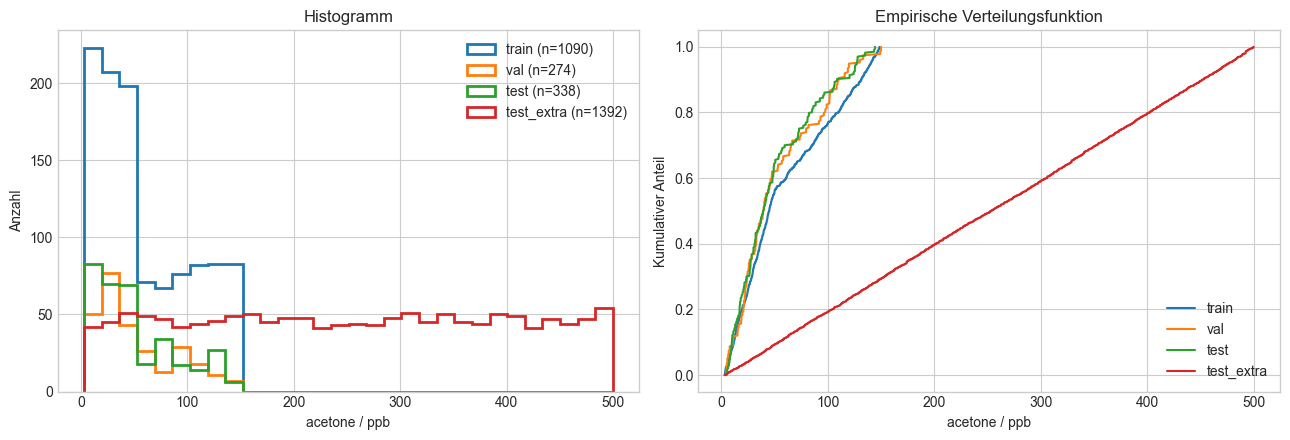

In [4]:
colors = {
    "train": "tab:blue", "val": "tab:orange",
    "test": "tab:green", "test_extra": "tab:red",
}
all_y = np.concatenate([
    splits[name]["targets"][GAS] for name in SPLIT_NAMES
])
bins = np.linspace(all_y.min(), all_y.max(), 31)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for split in SPLIT_NAMES:
    y = splits[split]["targets"][GAS]
    axes[0].hist(
        y, bins=bins, histtype="step", linewidth=2,
        label=f"{split} (n={len(y)})", color=colors[split]
    )
    sorted_y = np.sort(y)
    axes[1].plot(
        sorted_y, np.linspace(0, 1, len(sorted_y)),
        label=split, color=colors[split]
    )
axes[0].set(xlabel=f"{GAS} / ppb", ylabel="Anzahl", title="Histogramm")
axes[1].set(
    xlabel=f"{GAS} / ppb", ylabel="Kumulativer Anteil",
    title="Empirische Verteilungsfunktion"
)
for ax in axes:
    ax.legend()
plt.tight_layout()

## 3. Target über der UGM-ID

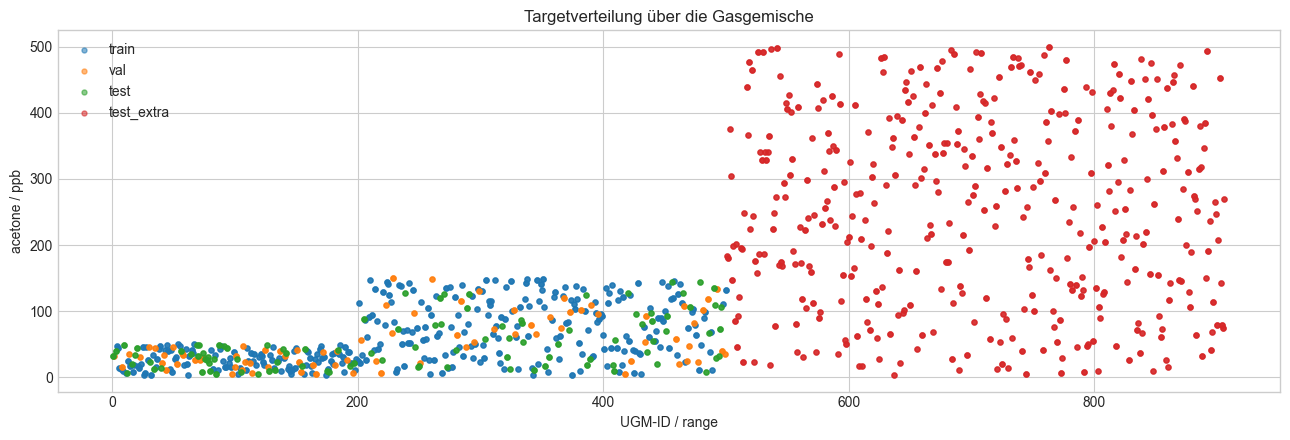

In [5]:
plt.figure(figsize=(13, 4.5))
for split in SPLIT_NAMES:
    plt.scatter(
        splits[split]["targets"]["range"],
        splits[split]["targets"][GAS],
        s=13, alpha=0.55, label=split, color=colors[split]
    )
plt.xlabel("UGM-ID / range")
plt.ylabel(f"{GAS} / ppb")
plt.title("Targetverteilung über die Gasgemische")
plt.legend()
plt.tight_layout()

## 4. Vollständiges Rohsignal mit Schwankungsbereich

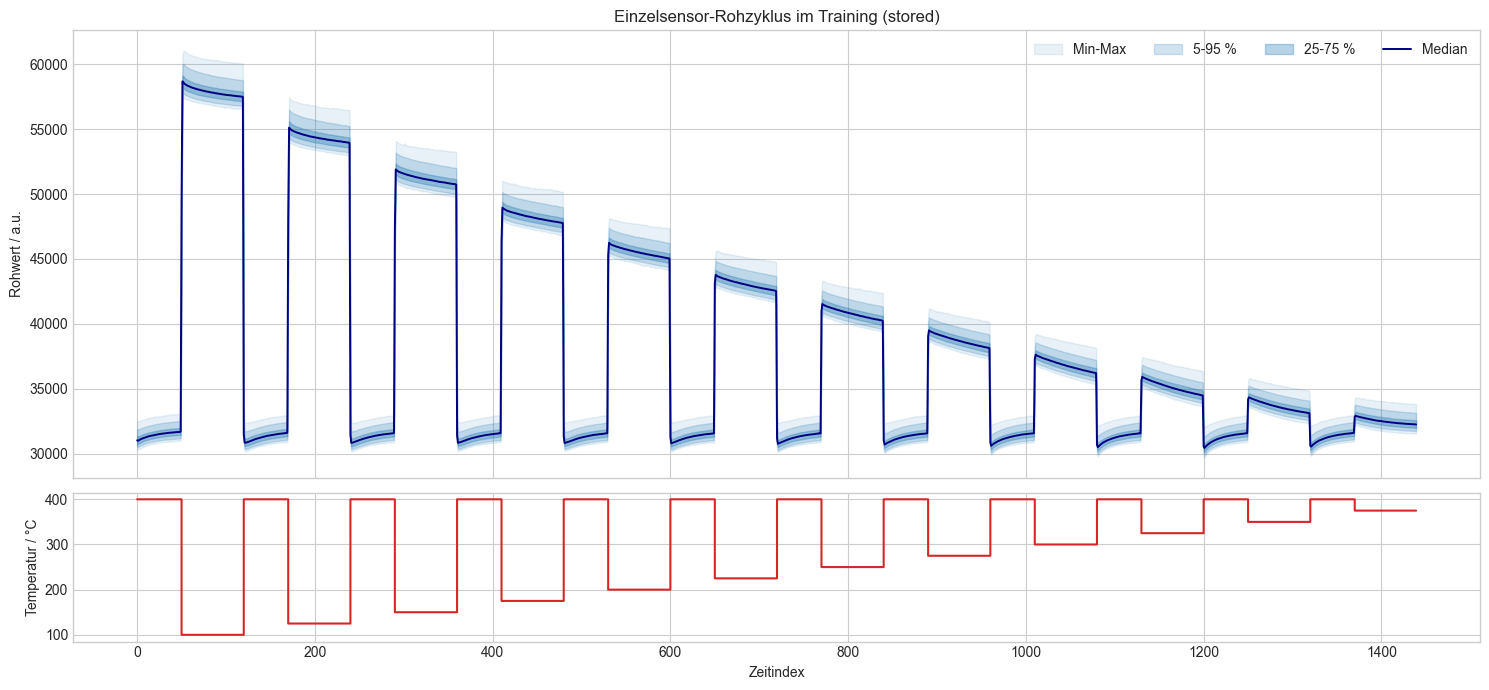

In [6]:
X_train = splits["train"]["X"][:, 0, :]
x_axis = np.arange(CYCLE_SAMPLES)
q05, q25, median, q75, q95 = np.quantile(
    X_train, [0.05, 0.25, 0.50, 0.75, 0.95], axis=0
)
minimum = X_train.min(axis=0)
maximum = X_train.max(axis=0)

fig, axes = plt.subplots(
    2, 1, figsize=(15, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)
axes[0].fill_between(
    x_axis, minimum, maximum, color="tab:blue", alpha=0.10,
    label="Min-Max"
)
axes[0].fill_between(
    x_axis, q05, q95, color="tab:blue", alpha=0.20,
    label="5-95 %"
)
axes[0].fill_between(
    x_axis, q25, q75, color="tab:blue", alpha=0.32,
    label="25-75 %"
)
axes[0].plot(x_axis, median, color="navy", linewidth=1.4, label="Median")
axes[0].set(
    ylabel="Rohwert / a.u.",
    title=f"Einzelsensor-Rohzyklus im Training ({TRANSFORM})"
)
axes[0].legend(ncol=4)
axes[1].step(
    x_axis, temperature_profile(), where="post", color="tab:red"
)
axes[1].set(xlabel="Zeitindex", ylabel="Temperatur / °C")
plt.tight_layout()

Das Min-Max-Band zeigt alle beobachteten Extremwerte. Die Quantilbänder
sind robuster und zeigen, in welchem Bereich die meisten Rohsignale
tatsächlich schwanken.

## 5. Beispielzyklen bei niedrigen, mittleren und hohen Zielwerten

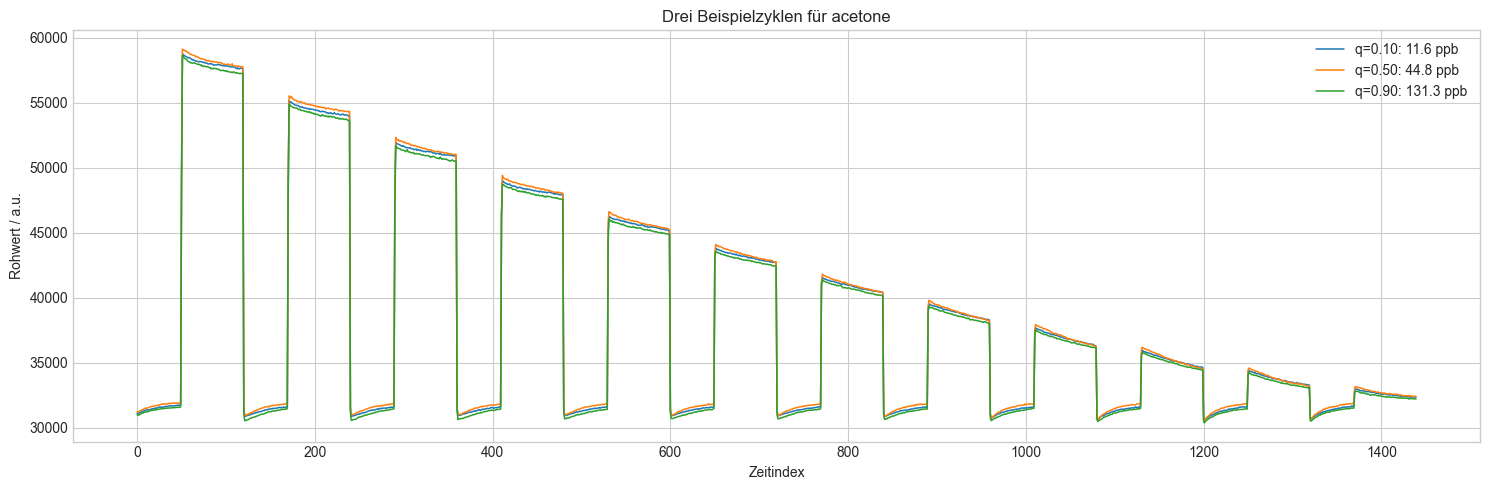

In [7]:
y_train = splits["train"]["targets"][GAS]
levels = (0.10, 0.50, 0.90)
fig, ax = plt.subplots(figsize=(15, 5))
for quantile in levels:
    wanted = np.quantile(y_train, quantile)
    index = int(np.argmin(np.abs(y_train - wanted)))
    ax.plot(
        X_train[index], linewidth=1.1,
        label=f"q={quantile:.2f}: {y_train[index]:.1f} ppb"
    )
ax.set(
    xlabel="Zeitindex", ylabel="Rohwert / a.u.",
    title=f"Drei Beispielzyklen für {GAS}"
)
ax.legend()
plt.tight_layout()

## 6. Zusammenhang des gewählten Gases mit allen 48 Grenzpunkten

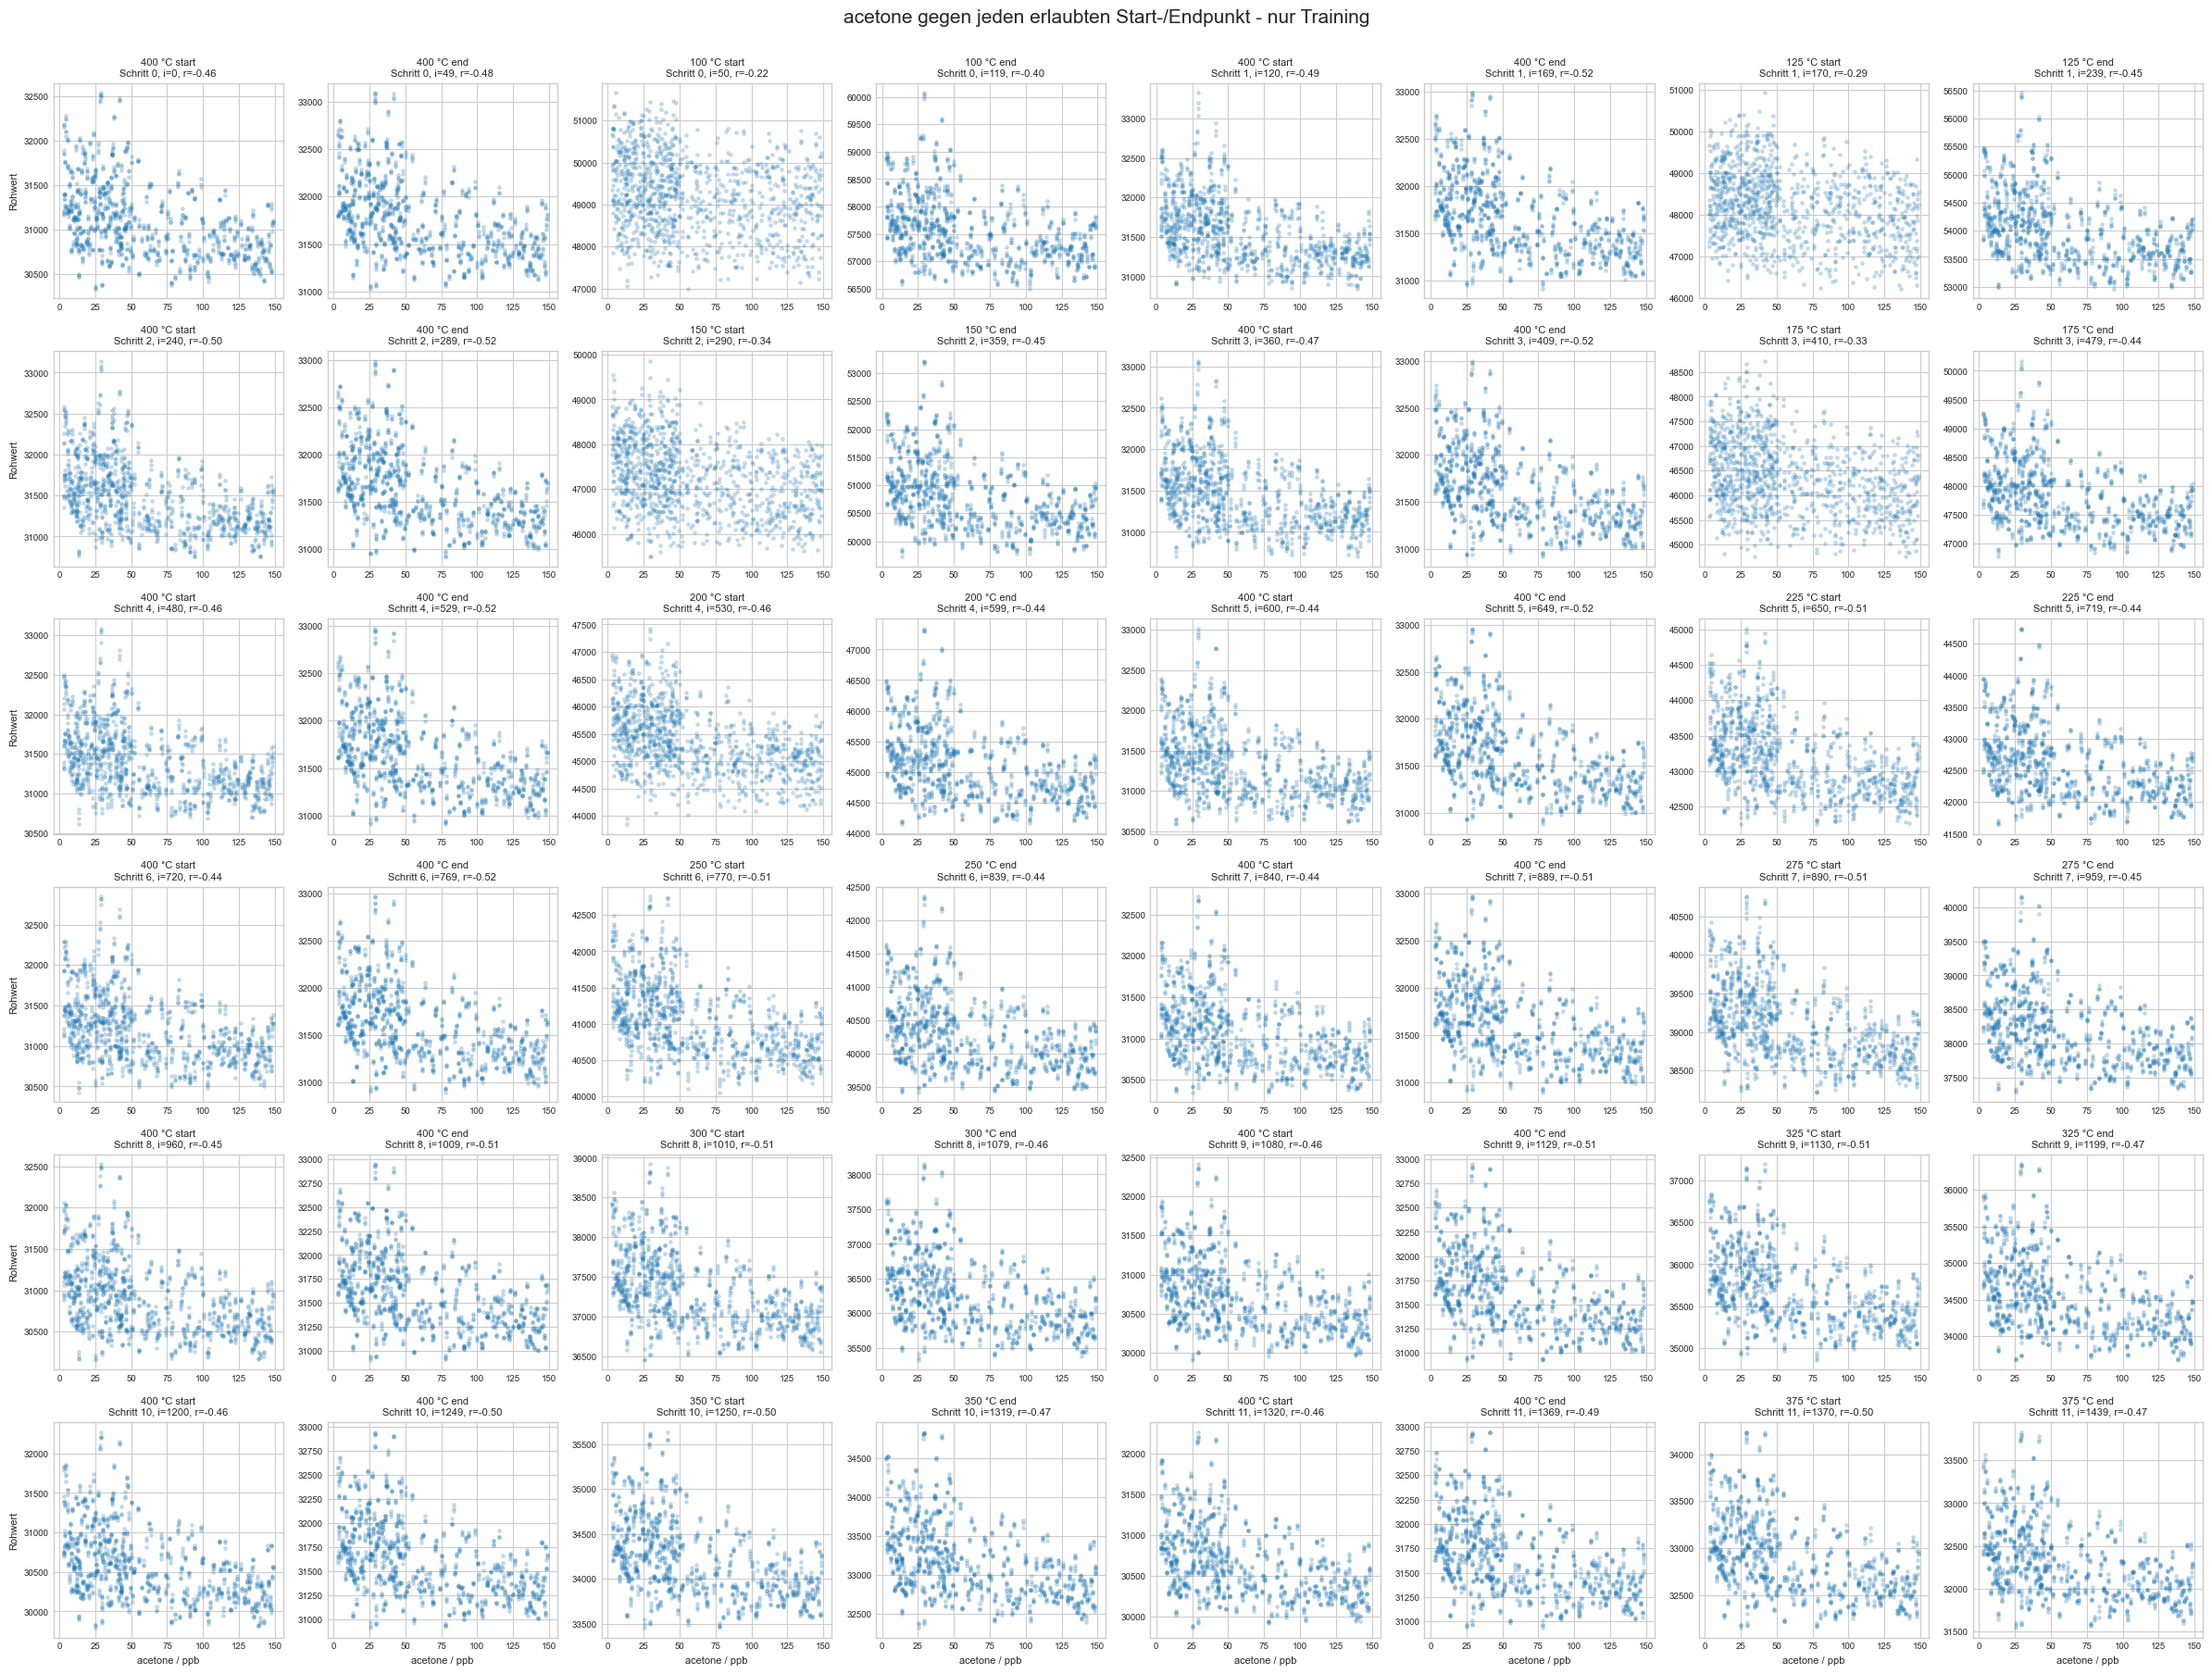

In [8]:
scores = score_boundary_points(splits, GAS)
fig, axes = plt.subplots(6, 8, figsize=(24, 18))
for ax, score in zip(axes.ravel(), scores):
    point_values = X_train[:, score.index]
    ax.scatter(
        y_train, point_values, s=6, alpha=0.20,
        color="tab:blue", rasterized=True
    )
    ax.set_title(
        f"{score.temperature_c} °C {score.edge}\n"
        f"Schritt {score.cycle_step}, i={score.index}, "
        f"r={score.target_correlation:+.2f}",
        fontsize=8
    )
    ax.tick_params(labelsize=7)
for ax in axes[-1]:
    ax.set_xlabel(f"{GAS} / ppb", fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("Rohwert", fontsize=8)
fig.suptitle(
    f"{GAS} gegen jeden erlaubten Start-/Endpunkt - nur Training",
    fontsize=15, y=1.002
)
plt.tight_layout()

## 7. Korrelationen der 48 Punkte im Überblick

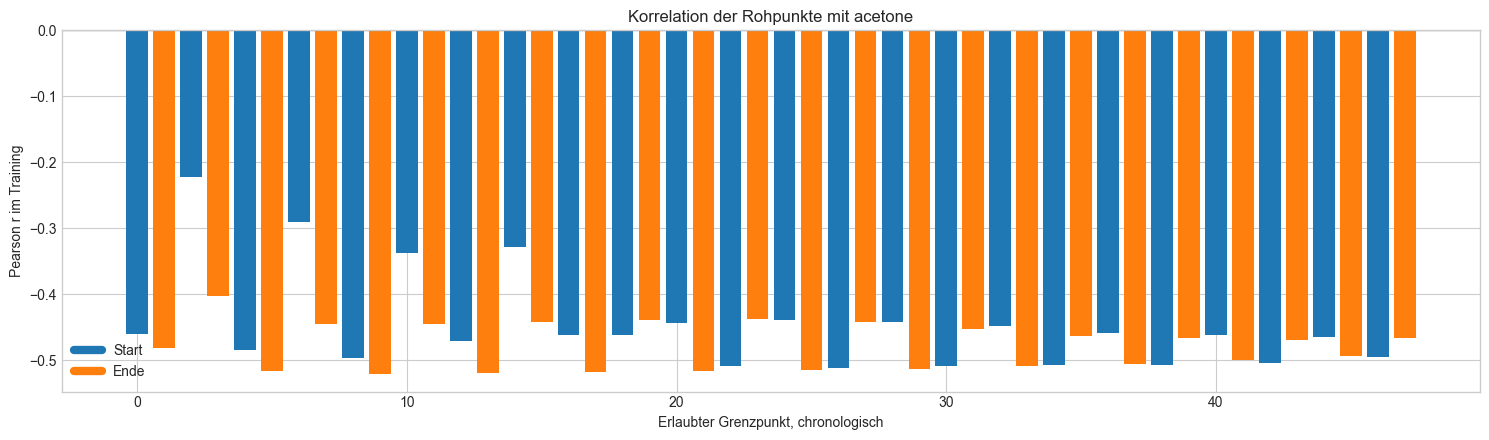

In [9]:
fig, ax = plt.subplots(figsize=(15, 4.5))
positions = np.arange(len(scores))
correlations = [score.target_correlation for score in scores]
point_colors = [
    "tab:blue" if score.edge == "start" else "tab:orange"
    for score in scores
]
ax.bar(positions, correlations, color=point_colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(
    xlabel="Erlaubter Grenzpunkt, chronologisch",
    ylabel="Pearson r im Training",
    title=f"Korrelation der Rohpunkte mit {GAS}"
)
ax.legend(
    handles=[
        plt.Line2D([0], [0], color="tab:blue", lw=6, label="Start"),
        plt.Line2D([0], [0], color="tab:orange", lw=6, label="Ende"),
    ]
)
plt.tight_layout()

## 8. Ausgewählte Punkte getrennt nach Split

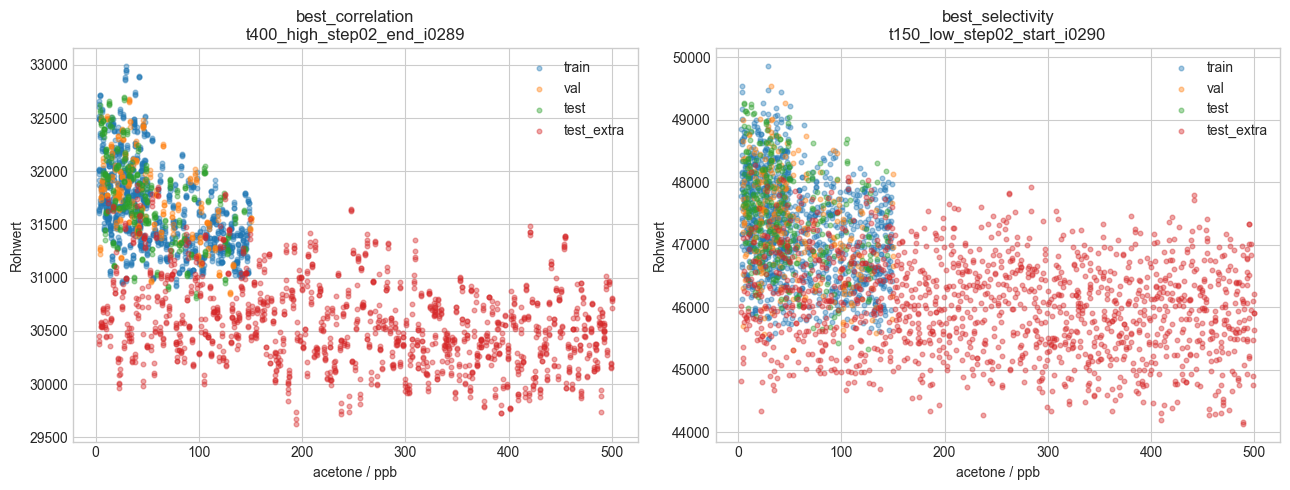

In [10]:
chosen = selected_point_scores(scores)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, selection in zip(
    axes, ("best_correlation", "best_selectivity")
):
    score = chosen[selection]
    for split in SPLIT_NAMES:
        ax.scatter(
            splits[split]["targets"][GAS],
            splits[split]["X"][:, 0, score.index],
            s=11, alpha=0.40, color=colors[split], label=split
        )
    ax.set(
        xlabel=f"{GAS} / ppb", ylabel="Rohwert",
        title=f"{selection}\n{score.point_id}"
    )
    ax.legend()
plt.tight_layout()

Die beiden Punkte wurden ausschließlich anhand des Trainingssplits
ausgewählt. Validation und Test werden hier nur nachträglich angezeigt.

## 9. R², MSE, RMSE und MAE für jeden Einzelpunkt

Fehlermaße benötigen Vorhersagen. Deshalb wird für jeden Grenzpunkt
separat die einfache Gerade Gas = a mal Rohwert plus b ausschließlich
im Training angepasst. Dieselbe unveränderte Gerade wird danach auf
Validation, Test und test_extra angewendet.

In [11]:
def prediction_metrics(y_true, y_pred):
    residual = np.asarray(y_true) - np.asarray(y_pred)
    mse = float(np.mean(residual ** 2))
    denominator = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = 1.0 - float(np.sum(residual ** 2)) / denominator
    return {
        "R2": r2,
        "MSE": mse,
        "RMSE": mse ** 0.5,
        "MAE": float(np.mean(np.abs(residual))),
    }


point_evaluations = []
for score in scores:
    x_train = splits["train"]["X"][:, 0, score.index].astype(float)
    y_fit = splits["train"]["targets"][GAS].astype(float)
    design = np.column_stack([x_train, np.ones(len(x_train))])
    slope, intercept = np.linalg.lstsq(
        design, y_fit, rcond=None
    )[0]

    metrics = {}
    for split in SPLIT_NAMES:
        x = splits[split]["X"][:, 0, score.index].astype(float)
        y = splits[split]["targets"][GAS].astype(float)
        prediction = slope * x + intercept
        metrics[split] = prediction_metrics(y, prediction)

    point_evaluations.append({
        "score": score,
        "slope": float(slope),
        "intercept": float(intercept),
        "metrics": metrics,
    })

ranked = sorted(
    point_evaluations,
    key=lambda item: item["metrics"]["val"]["RMSE"],
)
print("Die 12 Punkte mit kleinstem Validierungs-RMSE")
print(
    "Punkt                                "
    "R2 train   R2 val  R2 test R2 extra | "
    "RMSE train RMSE val RMSE test RMSE extra"
)
for item in ranked[:12]:
    score = item["score"]
    m = item["metrics"]
    print(
        f"{score.point_id:36s} "
        f"{m['train']['R2']:8.3f} {m['val']['R2']:8.3f} "
        f"{m['test']['R2']:8.3f} {m['test_extra']['R2']:8.3f} | "
        f"{m['train']['RMSE']:10.3f} {m['val']['RMSE']:8.3f} "
        f"{m['test']['RMSE']:9.3f} "
        f"{m['test_extra']['RMSE']:10.3f}"
    )

Die 12 Punkte mit kleinstem Validierungs-RMSE
Punkt                                R2 train   R2 val  R2 test R2 extra | RMSE train RMSE val RMSE test RMSE extra
t400_high_step03_end_i0409              0.270    0.288    0.235   -0.765 |     37.279   32.759    32.883    191.243
t400_high_step05_end_i0649              0.268    0.285    0.234   -0.770 |     37.353   32.840    32.919    191.490
t400_high_step04_end_i0529              0.269    0.284    0.235   -0.768 |     37.313   32.854    32.884    191.405
t400_high_step02_end_i0289              0.272    0.283    0.233   -0.768 |     37.236   32.890    32.921    191.409
t400_high_step01_end_i0169              0.267    0.281    0.227   -0.787 |     37.376   32.918    33.063    192.394
t400_high_step06_end_i0769              0.266    0.281    0.234   -0.776 |     37.393   32.922    32.912    191.791
t225_low_step05_start_i0650             0.260    0.281    0.231   -0.835 |     37.554   32.935    32.979    194.999
t300_low_step08_start_i101

## 10. Alle vier Metriken über die 48 Punkte

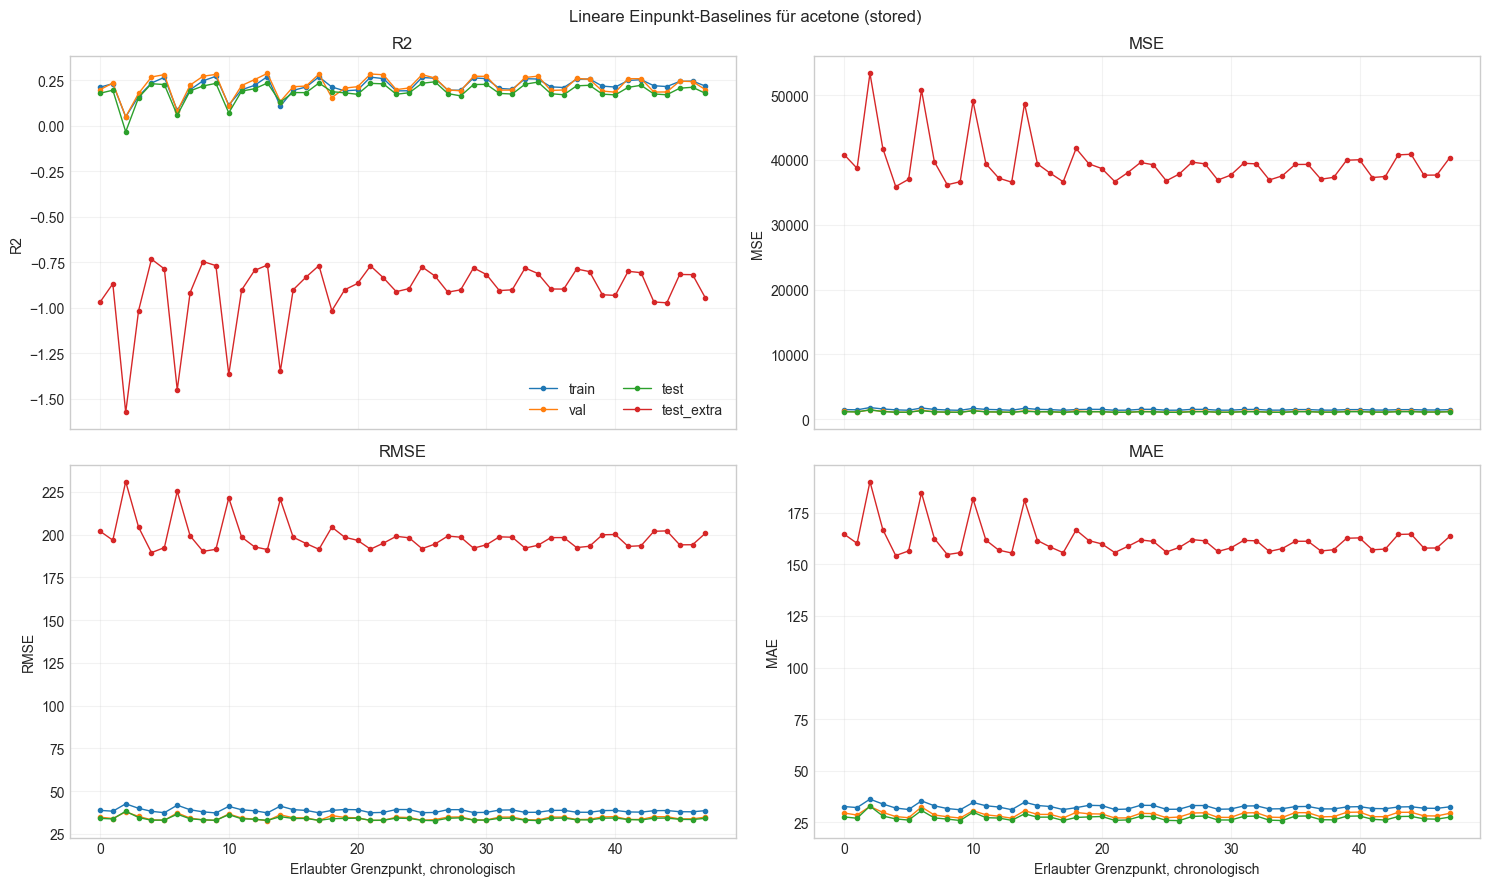

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
for ax, metric in zip(axes.ravel(), ("R2", "MSE", "RMSE", "MAE")):
    for split in SPLIT_NAMES:
        values = [
            item["metrics"][split][metric]
            for item in point_evaluations
        ]
        ax.plot(
            np.arange(len(values)), values, marker=".", linewidth=1,
            label=split, color=colors[split]
        )
    ax.set(title=metric, ylabel=metric)
    ax.grid(alpha=0.25)
for ax in axes[-1]:
    ax.set_xlabel("Erlaubter Grenzpunkt, chronologisch")
axes[0, 0].legend(ncol=2)
fig.suptitle(
    f"Lineare Einpunkt-Baselines für {GAS} ({TRANSFORM})"
)
plt.tight_layout()

## 11. Vollständige Metriken der beiden zuvor ausgewählten Punkte

In [13]:
by_index = {
    item["score"].index: item for item in point_evaluations
}
for selection in ("best_correlation", "best_selectivity"):
    score = chosen[selection]
    item = by_index[score.index]
    print(
        f"\n{selection}: {score.point_id}\n"
        f"Gerade: {GAS} = {item['slope']:.8g} * Rohwert "
        f"+ {item['intercept']:.8g}"
    )
    print("Split          R2           MSE          RMSE           MAE")
    for split in SPLIT_NAMES:
        m = item["metrics"][split]
        print(
            f"{split:10s} {m['R2']:11.4f} {m['MSE']:13.4f} "
            f"{m['RMSE']:13.4f} {m['MAE']:13.4f}"
        )


best_correlation: t400_high_step02_end_i0289
Gerade: acetone = -0.056327904 * Rohwert + 1842.989
Split          R2           MSE          RMSE           MAE
train           0.2721     1386.5422       37.2363       31.0304
val             0.2827     1081.7241       32.8896       27.0448
test            0.2334     1083.7839       32.9209       25.8329
test_extra     -0.7685    36637.2419      191.4086      155.7235

best_selectivity: t150_low_step02_start_i0290
Gerade: acetone = -0.018650017 * Rohwert + 941.41707
Split          R2           MSE          RMSE           MAE
train           0.1142     1687.3237       41.0770       34.5690
val             0.1102     1341.9565       36.6327       30.6130
test            0.0712     1313.1413       36.2373       29.8799
test_extra     -1.3670    49037.6509      221.4445      181.7138


Im Training gilt für diese lineare Regression mit Achsenabschnitt
R² = r². Außerhalb des Trainings ist das nicht garantiert; insbesondere
test_extra kann wegen des erweiterten Konzentrationsbereichs deutlich
schlechter oder sogar negativ ausfallen.